In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd
import skimage
import scipy
import sklearn.metrics

In [ ]:
metadata = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
screen = metadata[metadata.datasets == 'screen']
print(screen.iloc[3])

im = skimage.io.imread(f'/scr/yren/all_data_micronuclei/{screen.iloc[3]['split']}/{screen.iloc[3]['filenames']}')
gt = skimage.io.imread(f'/scr/yren/all_data_micronuclei/{screen.iloc[3]['split']}/{screen.iloc[3]['filenames'].replace('.phenotype.tif', '.phenotype_outlines.png')}')

ys, xs = np.where(gt == 32)
y, x = int(np.mean(ys)), int(np.mean(xs))
y, x

patch = 128
plt.imshow(im[y-patch:y+patch, x-patch:x+patch])
plt.axis('off')
plt.show()

In [ ]:
fig, ax = plt.subplots()

# Display the image
ax.imshow(im[y-patch:y+patch, x-patch:x+patch])

# Add grid lines
ax.grid(True, color='white')

plt.show()

In [ ]:
crop = im[y-patch:y+patch, x-patch:x+patch]
print(crop.shape)
H, W = crop.shape
PS = 50
patches_per_image = (W // PS) * (H // PS)
print(f'height - {H}, width - {W}, patches - {patches_per_image}')
X = np.linspace(0, W - W % PS, W // PS + 1)
Y = np.linspace(0, H - H % PS, H // PS + 1)
X,Y = np.meshgrid(X[:-1],Y[:-1], indexing='ij')
X = X.reshape((patches_per_image,))
Y = Y.reshape((patches_per_image,))
C = np.stack((Y,X)).T

coords = C[0:9]

fig, ax = plt.subplots(1,9, figsize=(10,10))
for i in range(len(coords)):
    coord = coords[i]
    r, c = int(coord[0]), int(coord[1])
    image = crop[r:r+PS, c:c+PS]
    ax[i].imshow(image)

    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].axis('off')
plt.show()
    

# Analysis on 47 validation images

# Swarmplot

In [17]:
with open('/scr/yren/swarmplot_prediction_output_model_v3.txt', 'r') as f:
    lines = [line.rstrip('\n') for line in f.readlines()]

lines[0:3]

['2022-05-26_RPE1-2198,0.9596,0.8407',
 '2022-10-14_U2OS-1,0.8182,0.8571',
 '2023-05-31_misc-4,0.5714,1.0000']

In [18]:
data = [line.strip().split(',') for line in lines]  # Strip to remove any trailing newlines
metrics = pd.DataFrame(data, columns=['imid', 'precision', 'recall'])
# Convert 'precision' and 'recall' to float
metrics[['precision', 'recall']] = metrics[['precision', 'recall']].astype(float)
metrics['model'] = 'model_v3'

In [19]:
metrics.head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.9596,0.8407,model_v3
1,2022-10-14_U2OS-1,0.8182,0.8571,model_v3
2,2023-05-31_misc-4,0.5714,1.0000,model_v3
3,20X_c0-DAPI_A1_Tile-50,0.7967,0.8896,model_v3
4,C1-20X_c0_B3_Tile-24,0.7068,0.9507,model_v3


In [20]:
with open('/scr/yren/mnfinder_eval_output.txt', 'r') as f:
    lines_mnfinder = [line.rstrip('\n') for line in f.readlines()]
lines_mnfinder[0:3]

['2022-05-26_RPE1-2198,0.7328,0.7589',
 '2022-10-14_U2OS-1,0.7447,0.5738',
 '2023-05-31_misc-4,0.6667,1.0000']

In [22]:
data_mnfinder = [line.strip().split(',') for line in lines_mnfinder]  # Strip to remove any trailing newlines
metrics_mnfinder = pd.DataFrame(data_mnfinder, columns=['imid', 'precision', 'recall'])
# Convert 'precision' and 'recall' to float
metrics_mnfinder[['precision', 'recall']] = metrics_mnfinder[['precision', 'recall']].astype(float)
metrics_mnfinder['model'] = 'mnfinder'
metrics_mnfinder.head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.7328,0.7589,mnfinder
1,2022-10-14_U2OS-1,0.7447,0.5738,mnfinder
2,2023-05-31_misc-4,0.6667,1.0000,mnfinder
3,20X_c0-DAPI_A1_Tile-50,0.7517,0.6687,mnfinder
4,C1-20X_c0_B3_Tile-24,0.6100,0.8652,mnfinder


In [28]:
with open('/scr/yren/cellpose_eval_output.txt', 'r') as f:
    lines_cellpose = [line.rstrip('\n') for line in f.readlines()]
lines_cellpose[0:3]

['2022-05-26_RPE1-2198,0.1905,0.2124',
 '2022-10-14_U2OS-1,0.0246,0.0476',
 '2023-05-31_misc-4,0.0625,0.2500']

In [30]:
data_cellpose = [line.strip().split(',') for line in lines_cellpose]  # Strip to remove any trailing newlines
metrics_cellpose = pd.DataFrame(data_cellpose, columns=['imid', 'precision', 'recall'])
# Convert 'precision' and 'recall' to float
metrics_cellpose[['precision', 'recall']] = metrics_cellpose[['precision', 'recall']].astype(float)
metrics_cellpose['model'] = 'cellpose'
metrics_cellpose.head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.1905,0.2124,cellpose
1,2022-10-14_U2OS-1,0.0246,0.0476,cellpose
2,2023-05-31_misc-4,0.0625,0.2500,cellpose
3,20X_c0-DAPI_A1_Tile-50,0.0027,0.0245,cellpose
4,C1-20X_c0_B3_Tile-24,0.0082,0.0704,cellpose


In [31]:
df = pd.concat([metrics, metrics_mnfinder, metrics_cellpose])
df

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.9596,0.8407,model_v3
1,2022-10-14_U2OS-1,0.8182,0.8571,model_v3
2,2023-05-31_misc-4,0.5714,1.0000,model_v3
3,20X_c0-DAPI_A1_Tile-50,0.7967,0.8896,model_v3
4,C1-20X_c0_B3_Tile-24,0.7068,0.9507,model_v3
...,...,...,...,...
42,IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1...,0.0108,0.1538,cellpose
43,IXMtest_N18_s2_w1CC5ED51D-86C5-437D-8EDD-E56E4...,0.0246,0.3333,cellpose
44,IXMtest_O09_s2_w133C7EDCE-1C7C-41A6-9E52-7AD49...,0.0141,0.1111,cellpose
45,IXMtest_O16_s2_w1F6F6A3A1-99E4-4029-B734-02280...,0.0339,0.4000,cellpose


/tmp/ipykernel_2337939/3883583831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='recall', y='model', palette='bright')


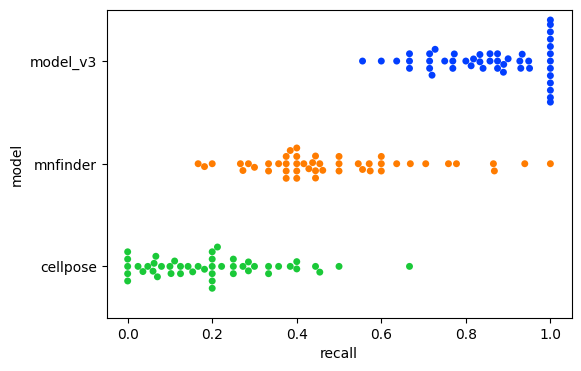

In [32]:
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x='recall', y='model', palette='bright')
plt.show()

/tmp/ipykernel_2337939/1603537297.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='precision', y='model', palette='bright')
/scr/yren/miniconda3/envs/micronuclei-detection/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 17.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/scr/yren/miniconda3/envs/micronuclei-detection/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


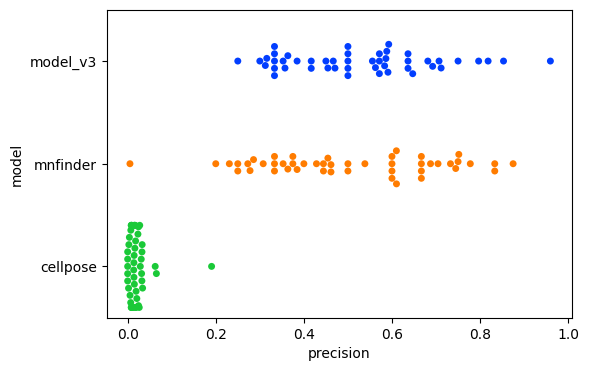

In [33]:
plt.figure(figsize=(6, 4))
sns.swarmplot(data=df, x='precision', y='model', palette='bright')
plt.show()

In [26]:
df[df.model=='model_v3'].head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.9596,0.8407,model_v3
1,2022-10-14_U2OS-1,0.8182,0.8571,model_v3
2,2023-05-31_misc-4,0.5714,1.0000,model_v3
3,20X_c0-DAPI_A1_Tile-50,0.7967,0.8896,model_v3
4,C1-20X_c0_B3_Tile-24,0.7068,0.9507,model_v3


In [27]:
df[df.model=='mnfinder'].head()

,imid,precision,recall,model
0,2022-05-26_RPE1-2198,0.7328,0.7589,mnfinder
1,2022-10-14_U2OS-1,0.7447,0.5738,mnfinder
2,2023-05-31_misc-4,0.6667,1.0000,mnfinder
3,20X_c0-DAPI_A1_Tile-50,0.7517,0.6687,mnfinder
4,C1-20X_c0_B3_Tile-24,0.6100,0.8652,mnfinder


# IoU Analysis Example

In [2]:
def compare_two_labels(label_model, label_gt, return_IoU_matrix, debug=False):
    
    # get number of detected nuclei
    nb_nuclei_gt = np.max(label_gt)
    nb_nuclei_model = np.max(label_model)
    
    # catch the case of an empty picture in model and gt
    if nb_nuclei_gt == 0 and nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, 0, 1, np.empty(0)]     
        else:
            return [0, 0, 1]
    
    # catch the case of empty picture in model
    if nb_nuclei_model == 0:
        if(return_IoU_matrix):
            return [0, nb_nuclei_gt, 0, np.empty(0)]     
        else:
            return [0, nb_nuclei_gt, 0]
    
    # catch the case of empty picture in gt
    if nb_nuclei_gt == 0:
        if(return_IoU_matrix):
            return [nb_nuclei_model, 0, 0, np.empty(0)]     
        else:
            return [nb_nuclei_model, 0, 0]
    
    # build IoU matrix
    IoUs = np.full((nb_nuclei_gt, nb_nuclei_model), -1.0, dtype = np.float32)

    # calculate IoU for each nucleus index_gt in GT and nucleus index_pred in prediction    
    # TODO improve runtime of this algorithm
    for index_gt in range(1,nb_nuclei_gt+1):

        nucleus_gt = label_gt == index_gt
        number_gt = np.sum(nucleus_gt)

        for index_model in range(1,nb_nuclei_model+1):
            
            if debug:
                print(index_gt, "/", index_model)
            
            nucleus_model = label_model == index_model 
            number_model = np.sum(nucleus_model)
            
            same_and_1 = np.sum((nucleus_gt == nucleus_model) * nucleus_gt)
            
            IoUs[index_gt-1,index_model-1] = same_and_1 / (number_gt + number_model - same_and_1)
    
    # get matches and errors
    detection_map = (IoUs > 0.5)
    nb_matches = np.sum(detection_map)

    detection_rate = IoUs * detection_map
    
    nb_overdetection = nb_nuclei_model - nb_matches
    nb_underdetection = nb_nuclei_gt - nb_matches
    
    mean_IoU = np.mean(np.sum(detection_rate, axis = 1))
    
    if(return_IoU_matrix):
        result = [nb_overdetection, nb_underdetection, mean_IoU, IoUs]
    else:
        result = [nb_overdetection, nb_underdetection, mean_IoU]
    return result


In [3]:
def measures_at(threshold, IOU):
    matches = IOU > threshold
    
    true_positives = np.sum(matches, axis=1) == 1   # Correct objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    
    assert np.all(np.less_equal(true_positives, 1))
    assert np.all(np.less_equal(false_positives, 1))
    assert np.all(np.less_equal(false_negatives, 1))
    
    TP, FP, FN = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
    
    f1 = 2*TP / (2*TP + FP + FN + 1e-9)

    prec = TP / (TP + FP)

    rec = TP / (TP + FN)

    return f1, prec, rec, TP, FP, FN

In [4]:
prob = np.load("/Users/jcaicedo/Documents/code/micronuclei-detection/20X_c0-DAPI_A1_Tile-190._probabilities.npy")
gt = skimage.io.imread("~/dataset_v2/20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png")

In [5]:
prob.shape

(2, 2960, 2960)

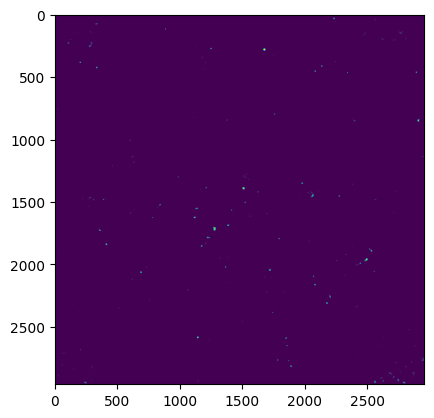

In [6]:
plt.imshow(prob[0,:,:])

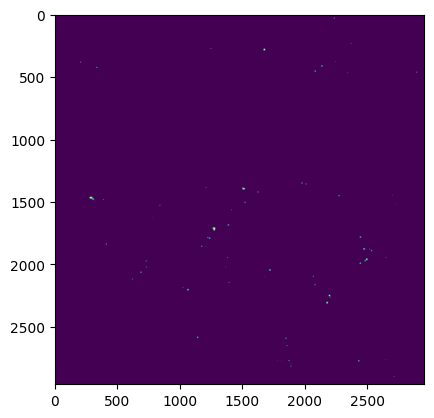

In [7]:
otl = gt[:,:,0] > 0
gt = scipy.ndimage.binary_fill_holes(otl) ^ otl
plt.imshow(gt)

In [8]:
jac = sklearn.metrics.jaccard_score(gt.flatten(), prob[0,:,:].flatten() > 0.5)

In [9]:
pred = prob[0,:,:] > 0.5
np.unique(pred)

array([False,  True])

In [10]:
pi = skimage.morphology.label(pred)
np.unique(pi)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72], dtype=int32)

In [11]:
gti = skimage.morphology.label(gt)
np.unique(gti)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73], dtype=int32)

In [12]:
nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)

In [13]:
nb_overdetection, nb_underdetection, mean_IoU

(56, 57, 0.13851525)

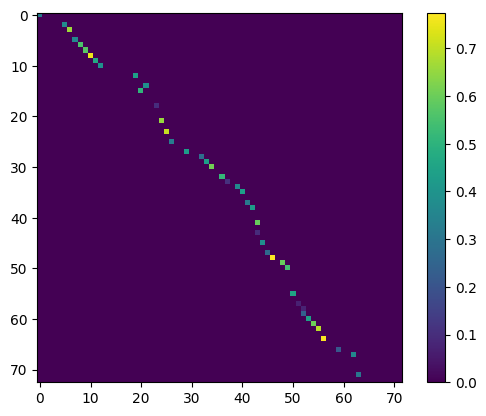

In [17]:
plt.imshow(IoUs)
plt.colorbar()

In [18]:
f1, prec, rec, TP, FP, FN = measures_at(0.1, IoUs)

In [19]:
f1, prec, rec, TP, FP, FN

(0.5655172413754103, 0.5694444444444444, 0.5616438356164384, 41, 31, 32)

# Save 47 Probabilities & IoUs

In [4]:
import os
import sys
sys.path.append('../')
import time
import torch
import skimage
import sklearn.metrics
import wandb

import numpy as np
import matplotlib.pyplot as plt

from microdet import mnds

In [9]:
# Hyperparameters
DIRECTORY = '/scr/yren/all_data_predictions/'
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [8]:
filelist = os.listdir(DIRECTORY)
files = [file for file in filelist if file.endswith('_probabilities.npy')]
print(len(files)) # 47 expected

47


In [10]:
im = np.load(DIRECTORY + files[0])
print(im.shape)

(1382, 1564)


In [14]:
for file in files:
    imid = file.split('.')[0]
    prob = np.load(DIRECTORY + file)
    mn_pred = prob > THRESHOLD
    mn_gt = mnds.read_image('/scr/yren/all_data_micronuclei/validation', imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)
    
    matches = IoUs > 0.1
    for i in range(0, matches.shape[0]):
        if (True in matches[i,:]):
            idx = np.where(matches[i,:]==True)[0][0]
            label_gt = i + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
    
    print(imid, matches.shape, len(np.unique(pi)))

    IoU_filename = f'/scr/yren/all_data_IoUs/{imid}._IoUs.npy'
    np.save(IoU_filename, matches)

2022-05-26_RPE1-2198 (113, 92) 93
2023-05-31_misc-4 (4, 7) 8
2022-10-14_U2OS-1 (63, 64) 65
20X_c0-DAPI_A1_Tile-50 (163, 180) 181
C1-20X_c0_B3_Tile-24 (142, 187) 188
C1-20X_c0_phalloidin_C3_Tile-15 (78, 100) 101
C2-20X_c0-DAPI-GFP_A2_Tile-5 (83, 113) 114
C2-20X_c0-DAPI-GFP_B3_Tile-16 (100, 107) 108
IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043 (9, 17) 18
IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78 (10, 18) 19
IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75 (7, 14) 15
IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1 (8, 14) 15
IXMtest_B24_s9_w18C4FE0DD-12CA-4711-9722-3E3105D1E691 (5, 16) 17
IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A (12, 19) 20
IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD (16, 26) 27
IXMtest_E06_s3_w1701573EB-CE9A-4D76-8668-0416996E1DCD (9, 12) 13
IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB (11, 11) 12
IXMtest_E12_s9_w1A811DEC0-ADD9-411A-B5D5-A654C70F253D (5, 12) 13
IXMtest_F08_s1_w144C3056F-C4DD-4D39-A40F-4F4576

## Scatter Plots

In [17]:
IoU_files = os.listdir('/scr/yren/all_data_IoUs/')
print(len(IoU_files))
IoU_files

47


['2022-05-26_RPE1-2198._IoUs.npy',
 '2023-05-31_misc-4._IoUs.npy',
 '2022-10-14_U2OS-1._IoUs.npy',
 '20X_c0-DAPI_A1_Tile-50._IoUs.npy',
 'C1-20X_c0_B3_Tile-24._IoUs.npy',
 'C1-20X_c0_phalloidin_C3_Tile-15._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_A2_Tile-5._IoUs.npy',
 'C2-20X_c0-DAPI-GFP_B3_Tile-16._IoUs.npy',
 'IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043._IoUs.npy',
 'IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78._IoUs.npy',
 'IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75._IoUs.npy',
 'IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1._IoUs.npy',
 'IXMtest_B24_s9_w18C4FE0DD-12CA-4711-9722-3E3105D1E691._IoUs.npy',
 'IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A._IoUs.npy',
 'IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD._IoUs.npy',
 'IXMtest_E06_s3_w1701573EB-CE9A-4D76-8668-0416996E1DCD._IoUs.npy',
 'IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB._IoUs.npy',
 'IXMtest_E12_s9_w1A811DEC0-ADD9-411A-B5D5-A654C70F253D._IoUs.npy',
 'IXMtest_F08_s1

In [19]:
import pandas as pd

df = pd.DataFrame(columns = ['original_area', 'predicted_area', 'status'])

for i in range(len(IoU_files)):
    path = '/scr/yren/all_data_IoUs/' + IoU_files[i]
    matches = np.load(path)
    
    imid = IoU_files[i].split('.')[0]
    prob = np.load(f'/scr/yren/all_data_predictions/{imid}._probabilities.npy')
    mn_pred = prob > THRESHOLD
    mn_gt = mnds.read_image('/scr/yren/all_data_micronuclei/validation', imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    
    original_area = []
    predicted_area = []
    status = [] # True/Flase
    
    for j in range(0, matches.shape[0]): # not detected should be 0 for predicted area
        if (True in matches[j,:]):
            idx = np.where(matches[j,:]==True)[0][0]
            label_gt = j + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Detected') # detected
            
        else: # ground truth is not predicted by the model
            area_gt = np.sum(gti == label_gt)
            area_pred = 0
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Missed') # not detected
            
    df_single_image = pd.DataFrame({'original_area':original_area, 'predicted_area':predicted_area, 'status':status})
    df = pd.concat([df, df_single_image], ignore_index=True)

In [20]:
df.to_csv('/scr/yren/model_v3_detection.csv')

In [21]:
df

,original_area,predicted_area,status
0,22,0,Missed
1,22,0,Missed
2,91,138,Detected
3,10,24,Detected
4,26,80,Detected
...,...,...,...
1134,96,145,Detected
1135,182,150,Detected
1136,24,165,Detected
1137,24,0,Missed


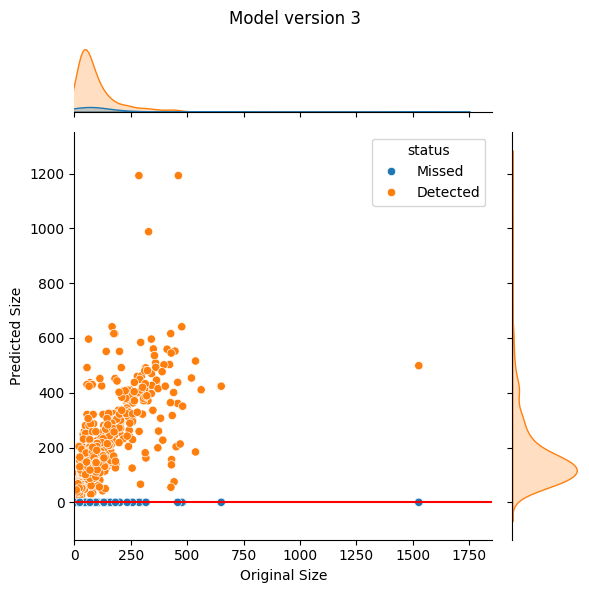

In [28]:
import seaborn as sns

pilot_figure = sns.jointplot(data=df, x='original_area', y='predicted_area', hue='status')
pilot_figure.figure.suptitle('Model version 3')
plt.axhline(y=0, color='red')
plt.xlabel('Original Size')
plt.ylabel('Predicted Size')
plt.xlim(left=0) 
plt.tight_layout()
plt.show()

In [ ]:
path = '/scr/yren/all_data_micronuclei/validation/'
save_path = '/scr/yren/validation_overlaps/'
overlaps = os.listdir(save_path)

for i in overlaps:
    imid = i.split('.')[0]
    overlap = np.load(save_path + i)
    pred = overlap[:,:,0]
    gt = overlap[:,:,2]
    # view = np.concatenate([255*pred[:,:,None], 255*gt[:,:,None], np.zeros_like(pred)[:,:,None]], axis=2)
    
    original_im = skimage.io.imread(path + i.replace('._overlap.npy', '.phenotype.tif'))
    cut = np.percentile(original_im,0.9)
    view = np.concatenate([255*pred[:,:,None], 255*gt[:,:,None], 255*(original_im[:,:,None]>cut)], axis=2)
    
    print(imid)
    fig, axs = plt.subplots(1,2, figsize=(30,30))
    axs[0].imshow(original_im)
    axs[0].set_title('Input')
    
    # axs[1].imshow(overlap)
    axs[1].imshow(view)
    axs[1].set_title('Overlaps')

    axs[0].axis('off')
    axs[1].axis('off')
    plt.show()
    plt.close('all')
    break
    # time.sleep(1)

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv('/scr/yren/all_data_micronuclei/metadata.csv')
np.unique(df.datasets.to_list())

array(['BBBC039', 'HeLa', 'RPE1', 'mnfinder_test', 'mnfinder_train',
       'mnfinder_validation', 'pilot', 'screen'], dtype='<U19')

,filenames,datasets,magnification,micron,split
24,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
25,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
26,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
27,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
28,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train
29,2022-03-18_RPE1-4.phenotype.tif,mnfinder_train,20,11.0,train
30,2022-05-26_RPE1-2.phenotype.tif,mnfinder_train,20,11.0,train
31,2022-05-26_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
32,2023-05-31_misc-10.phenotype.tif,mnfinder_train,20,11.0,train
33,2023-05-31_misc-11.phenotype.tif,mnfinder_train,20,11.0,train
